# MBA ZG582 - Applied Machine Learning and Deep Learning
## Assignment 2 - Phase 2: Machine Learning Phase
**Project:** Customer Churn Prediction for a Telecom Company Using Machine Learning  
**BITS ID:** 2024BC26597  
**Student:** HIRPARA RAMKRISHNA JAYANTILAL KANCHANBEN

This notebook reproduces the preprocessing, model training, tuning and evaluation reported in the Assignment 2 PDF.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, classification_report)
print('Environment ready.')

Environment ready.


In [2]:
# Portable dataset lookup: use a local copy when available; otherwise load directly from the public GitHub repository.
DATA_FILENAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
DATA_URL = "https://raw.githubusercontent.com/rkhirpara/AMLDL-Assignment-2-Telco-Churn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

candidates = [
    Path(DATA_FILENAME),
    Path('/content') / DATA_FILENAME,
    Path('/mnt/data/amldl_data') / DATA_FILENAME
]
DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is not None:
    print(f"Loading dataset from local path: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
else:
    print("Local dataset not found; loading directly from the public GitHub repository.")
    df = pd.read_csv(DATA_URL)

print('Shape:', df.shape)
print('Duplicate rows:', df.duplicated().sum())
print('Blank TotalCharges:', (df['TotalCharges'].astype(str).str.strip() == '').sum())
print('\nChurn distribution:')
print(df['Churn'].value_counts())
print('\nChurn rate:', round((df['Churn']=='Yes').mean()*100, 2), '%')
df.head()


Shape: (7043, 21)
Duplicate rows: 0
Blank TotalCharges: 11

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54 %


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn rate by contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: ChurnFlag, dtype: float64

Churn rate by tech support:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: ChurnFlag, dtype: float64

Churn rate by payment method:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: ChurnFlag, dtype: float64


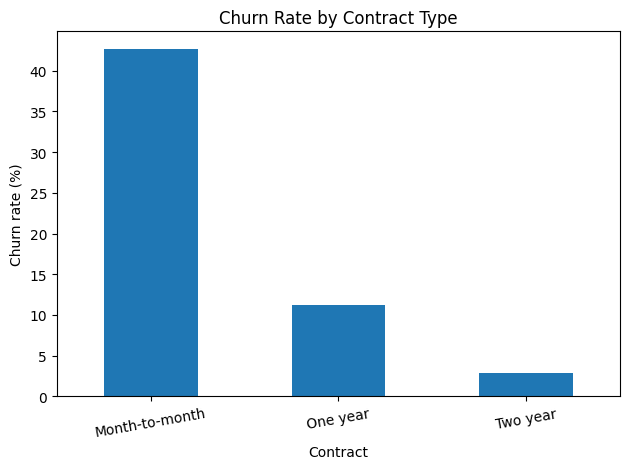

In [3]:
# Focused exploratory summaries
eda = df.assign(ChurnFlag=(df['Churn']=='Yes').astype(int))
print('Churn rate by contract:')
print((eda.groupby('Contract')['ChurnFlag'].mean()*100).round(1))
print('\nChurn rate by tech support:')
print((eda.groupby('TechSupport')['ChurnFlag'].mean()*100).round(1))
print('\nChurn rate by payment method:')
print((eda.groupby('PaymentMethod')['ChurnFlag'].mean()*100).round(1))

contract_rates=(eda.groupby('Contract')['ChurnFlag'].mean()*100).reindex(['Month-to-month','One year','Two year'])
contract_rates.plot(kind='bar', title='Churn Rate by Contract Type')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [4]:
# Prepare modelling data
model_df = df.copy()
model_df['TotalCharges'] = pd.to_numeric(model_df['TotalCharges'], errors='coerce')
model_df['Churn'] = (model_df['Churn']=='Yes').astype(int)
X = model_df.drop(columns=['Churn','customerID'])
y = model_df['Churn']

num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
cat_cols = [c for c in X.columns if c not in num_cols]
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print('Train / test:', X_train.shape, X_test.shape)

Train / test: (5634, 19) (1409, 19)


In [5]:
# Baseline models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

def evaluate(pipe):
    prob = pipe.predict_proba(X_test)[:,1]
    pred = (prob >= 0.50).astype(int)
    return {
        'Accuracy': accuracy_score(y_test,pred),
        'Precision': precision_score(y_test,pred),
        'Recall': recall_score(y_test,pred),
        'F1': f1_score(y_test,pred),
        'ROC-AUC': roc_auc_score(y_test,prob),
        'PR-AUC': average_precision_score(y_test,prob)
    }

baseline = {}
for name, model in base_models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train,y_train)
    baseline[name]=evaluate(pipe)
pd.DataFrame(baseline).T.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419,0.6334
Random Forest,0.7771,0.6020,0.4733,0.5299,0.8186,0.6075
Gradient Boosting,0.8062,0.6735,0.5241,0.5895,0.8434,0.6641


In [6]:
# Hyperparameter tuning on training data only
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([('preprocess',preprocessor),('model',LogisticRegression(max_iter=3000,random_state=42))])
lr_grid = {'model__C':[0.05,0.1,0.5,1,2,5,10], 'model__class_weight':[None,'balanced'], 'model__solver':['liblinear']}
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring='roc_auc', cv=cv5, n_jobs=-1, refit=True).fit(X_train,y_train)

rf_pipe = Pipeline([('preprocess',preprocessor),('model',RandomForestClassifier(random_state=42,n_jobs=-1))])
rf_params = {
    'model__n_estimators':[120,180,240], 'model__max_depth':[6,10,14,None],
    'model__min_samples_leaf':[1,3,6], 'model__max_features':['sqrt',0.5],
    'model__class_weight':[None,'balanced']
}
rf_search = RandomizedSearchCV(rf_pipe, rf_params, n_iter=8, scoring='roc_auc', cv=3, n_jobs=-1, random_state=42, refit=True).fit(X_train,y_train)

gb_pipe = Pipeline([('preprocess',preprocessor),('model',GradientBoostingClassifier(random_state=42))])
gb_grid = {'model__n_estimators':[80,120,160], 'model__learning_rate':[0.05,0.1], 'model__max_depth':[1,2]}
gb_search = GridSearchCV(gb_pipe, gb_grid, scoring='roc_auc', cv=3, n_jobs=-1, refit=True).fit(X_train,y_train)

print('Best Logistic Regression:', lr_search.best_params_, 'CV AUC=', round(lr_search.best_score_,4))
print('Best Random Forest:', rf_search.best_params_, 'CV AUC=', round(rf_search.best_score_,4))
print('Best Gradient Boosting:', gb_search.best_params_, 'CV AUC=', round(gb_search.best_score_,4))

Best Logistic Regression: {'model__C': 10, 'model__class_weight': None, 'model__solver': 'liblinear'} CV AUC= 0.8463
Best Random Forest: {'model__n_estimators': 180, 'model__min_samples_leaf': 6, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced'} CV AUC= 0.8488
Best Gradient Boosting: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 80} CV AUC= 0.8495


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.8048,0.6552,0.5588,0.6032,0.8411,0.6281
Random Forest,0.7658,0.5417,0.7647,0.6341,0.8418,0.6520
Gradient Boosting,0.7956,0.6514,0.4947,0.5623,0.8458,0.6639


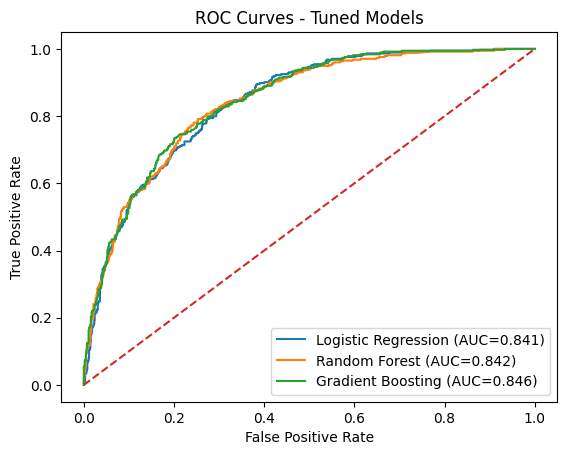

In [7]:
# Tuned-model hold-out comparison
tuned_models = {
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'Gradient Boosting': gb_search.best_estimator_
}
rows=[]
probs={}
for name, pipe in tuned_models.items():
    prob=pipe.predict_proba(X_test)[:,1]; probs[name]=prob
    pred=(prob>=0.50).astype(int)
    rows.append([name, accuracy_score(y_test,pred), precision_score(y_test,pred),
                 recall_score(y_test,pred), f1_score(y_test,pred),
                 roc_auc_score(y_test,prob), average_precision_score(y_test,prob)])
results = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']).set_index('Model')
display(results.round(4))

for name,prob in probs.items():
    fpr,tpr,_=roc_curve(y_test,prob)
    plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,prob):.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curves - Tuned Models'); plt.legend(); plt.show()

Confusion matrix:
 [[793 242]
 [ 88 286]]

Classification report:
               precision    recall  f1-score   support

           0      0.900     0.766     0.828      1035
           1      0.542     0.765     0.634       374

    accuracy                          0.766      1409
   macro avg      0.721     0.765     0.731      1409
weighted avg      0.805     0.766     0.776      1409



,feature,importance
36,Contract_Month-to-month,0.128766
1,tenure,0.125732
3,TotalCharges,0.091888
18,OnlineSecurity_No,0.070914
38,Contract_Two year,0.068558
2,MonthlyCharges,0.064012
27,TechSupport_No,0.057769
16,InternetService_Fiber optic,0.053525
43,PaymentMethod_Electronic check,0.037207
21,OnlineBackup_No,0.018801


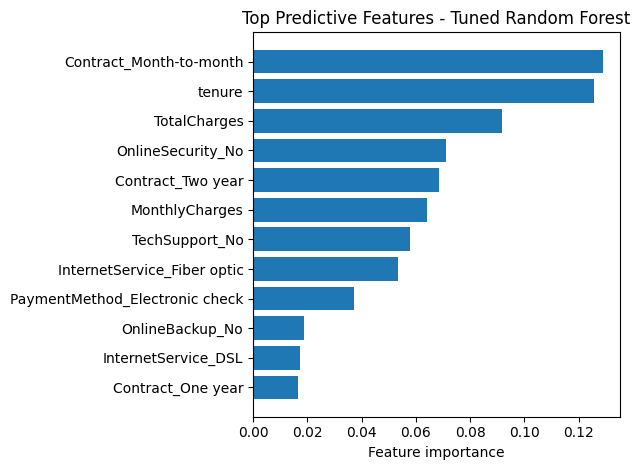

In [8]:
# Final operational model: tuned Random Forest
final_model = rf_search.best_estimator_
rf_prob = final_model.predict_proba(X_test)[:,1]
rf_pred = (rf_prob>=0.50).astype(int)
print('Confusion matrix:\n', confusion_matrix(y_test,rf_pred))
print('\nClassification report:\n', classification_report(y_test,rf_pred,digits=3))

feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
importances = final_model.named_steps['model'].feature_importances_
fi = pd.DataFrame({'feature':feature_names,'importance':importances}).sort_values('importance',ascending=False)
fi['feature'] = fi['feature'].str.replace('num__','',regex=False).str.replace('cat__','',regex=False)
display(fi.head(12))

top=fi.head(12).sort_values('importance')
plt.barh(top['feature'], top['importance'])
plt.title('Top Predictive Features - Tuned Random Forest')
plt.xlabel('Feature importance')
plt.tight_layout(); plt.show()

## Business interpretation

The tuned Random Forest is selected as the operational churn-screening model because its recall is substantially higher than the alternatives at the default threshold while maintaining a useful ROC-AUC. This means the model captures a larger share of actual churners, which aligns with the retention objective. The most important signals include month-to-month contracts, tenure, TotalCharges, absence of online security/technical support, monthly charges, fiber-optic service and electronic-check payment.

In deployment, predicted probabilities should be used as risk scores. The classification threshold should be optimized against retention-offer cost, customer lifetime value and available campaign capacity rather than fixed permanently at 0.50.